# Aqui vienen los modelos desde las tablas SQL generadas (omie_features)

In [1]:
import sqlite3
import pandas as pd
import numpy as np
import os
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error
import matplotlib.pyplot as plt

base_dir = os.path.abspath(os.path.join(os.getcwd(), ".."))
db_path = os.path.join(base_dir, "data", "electricity.db")
conn = sqlite3.connect(db_path)

df = pd.read_sql("""
    SELECT * FROM omie_features
    ORDER BY datetime
""", conn)

conn.close()

print(df.shape)
df.head()

(8399, 21)


,year,month,day,hour,price_es,price_pt,datetime,hour_sin,hour_cos,day_of_year,...,doy_cos,weekday,weekday_sin,weekday_cos,lag_1,lag_24,lag_168,rolling_mean_24,rolling_mean_168,is_weekend
0,2023,1.0,15.0,1.0,25.00,25.00,2023-01-15 00:00:00,0.258819,0.965926,15,...,0.966848,6,-0.781831,0.62349,35.00,80.00,7.00,52.997500,74.781071,1
1,2023,1.0,15.0,2.0,17.08,17.08,2023-01-15 01:00:00,0.500000,0.866025,15,...,0.966848,6,-0.781831,0.62349,25.00,73.50,5.00,50.705833,74.888214,1
2,2023,1.0,15.0,3.0,13.94,13.94,2023-01-15 02:00:00,0.707107,0.707107,15,...,0.966848,6,-0.781831,0.62349,17.08,65.91,4.20,48.355000,74.960119,1
3,2023,1.0,15.0,4.0,4.16,4.16,2023-01-15 03:00:00,0.866025,0.500000,15,...,0.966848,6,-0.781831,0.62349,13.94,49.95,4.16,46.189583,75.018095,1
4,2023,1.0,15.0,5.0,3.10,3.10,2023-01-15 04:00:00,0.965926,0.258819,15,...,0.966848,6,-0.781831,0.62349,4.16,45.37,4.16,44.281667,75.018095,1


## Primero a definir variables (features y prediction) 

In [2]:
# Features y target
features = [
    "hour_sin", "hour_cos",
    "doy_sin", "doy_cos", 
    "weekday_sin", "weekday_cos",
    "is_weekend",
    "lag_1", "lag_24", "lag_168",
    "rolling_mean_24", "rolling_mean_168"
]

target = "price_es"

X = df[features]
y = df[target]

# Split temporal 80/20
split = int(len(df) * 0.8)
X_train, X_test = X.iloc[:split], X.iloc[split:]
y_train, y_test = y.iloc[:split], y.iloc[split:]

print(f"Train: {len(X_train)} filas")
print(f"Test: {len(X_test)} filas")

Train: 6719 filas
Test: 1680 filas


### Ahora comparemos 3 modelos. Uno tonto de baseline, Ridge y Random Forest

In [3]:
# Baseline — predecir siempre lag_24 (precio de ayer a la misma hora)
baseline_pred = X_test["lag_24"]
baseline_mae = mean_absolute_error(y_test, baseline_pred)
print(f"Baseline (lag_24): MAE = {baseline_mae:.2f}")

# Ridge Regression
ridge = Ridge()
ridge.fit(X_train, y_train)
ridge_pred = ridge.predict(X_test)
ridge_mae = mean_absolute_error(y_test, ridge_pred)
print(f"Ridge: MAE = {ridge_mae:.2f}")

# Random Forest
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)
rf_mae = mean_absolute_error(y_test, rf_pred)
print(f"Random Forest: MAE = {rf_mae:.2f}")

Baseline (lag_24): MAE = 23.46
Ridge: MAE = 8.06
Random Forest: MAE = 7.47


In [8]:
mae_train = mean_absolute_error(y_train, rf.predict(X_train))
mae_pred = mean_absolute_error(y_test, rf.predict(X_test))
print(f"Random Forest: MAE from train = {mae_train:.2f}")
print(f"Random Forest: MAE from prediction = {mae_pred:.2f}")

Random Forest: MAE from train = 2.20
Random Forest: MAE from prediction = 7.47


El baseline de 23.46 confirma que los modelos están aprendiendo de verdad — tanto Ridge como Random Forest lo superan ampliamente.
La diferencia entre Ridge (8.06) y Random Forest (7.47) es pequeña pero el RF gana, lo que sugiere que hay algo de no-linealidad en los datos.

In [4]:
from xgboost import XGBRegressor

xgb = XGBRegressor(n_estimators=100, random_state=42, verbosity=0)
xgb.fit(X_train, y_train)
xgb_pred = xgb.predict(X_test)
xgb_mae = mean_absolute_error(y_test, xgb_pred)
print(f"XGBoost: MAE = {xgb_mae:.2f}")

XGBoost: MAE = 9.45


In [5]:
mae_train = mean_absolute_error(y_train, xgb.predict(X_train))
mae_pred = mean_absolute_error(y_test, xgb.predict(X_test))
print(f"XGBoost: MAE from train = {mae_train:.2f}")
print(f"XGBoost: MAE from prediction = {mae_pred:.2f}")

XGBoost: MAE from train = 2.66
XGBoost: MAE from prediction = 9.45


In [6]:
xgb = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    random_state=42,
    verbosity=0
)
xgb.fit(X_train, y_train)
xgb_pred = xgb.predict(X_test)
xgb_mae = mean_absolute_error(y_test, xgb_pred)
print(f"XGBoost tuned: MAE = {xgb_mae:.2f}")

XGBoost tuned: MAE = 8.80


In [7]:
mae_train = mean_absolute_error(y_train, xgb.predict(X_train))
mae_pred = mean_absolute_error(y_test, xgb.predict(X_test))
print(f"XGBoost: MAE from train = {mae_train:.2f}")
print(f"XGBoost: MAE from prediction = {mae_pred:.2f}")

XGBoost: MAE from train = 3.53
XGBoost: MAE from prediction = 8.80


Los modelos de ensemble muestran overfitting significativo con un año de datos (MAE train 2.20 vs MAE prediction 7.47 en Random Forest, aun peor en XGBoost), confirmando que el histórico completo es necesario para capturar patrones estacionales completos. La division 80/20 es problematica al querer describir estaciones que no ha visto previamente. 

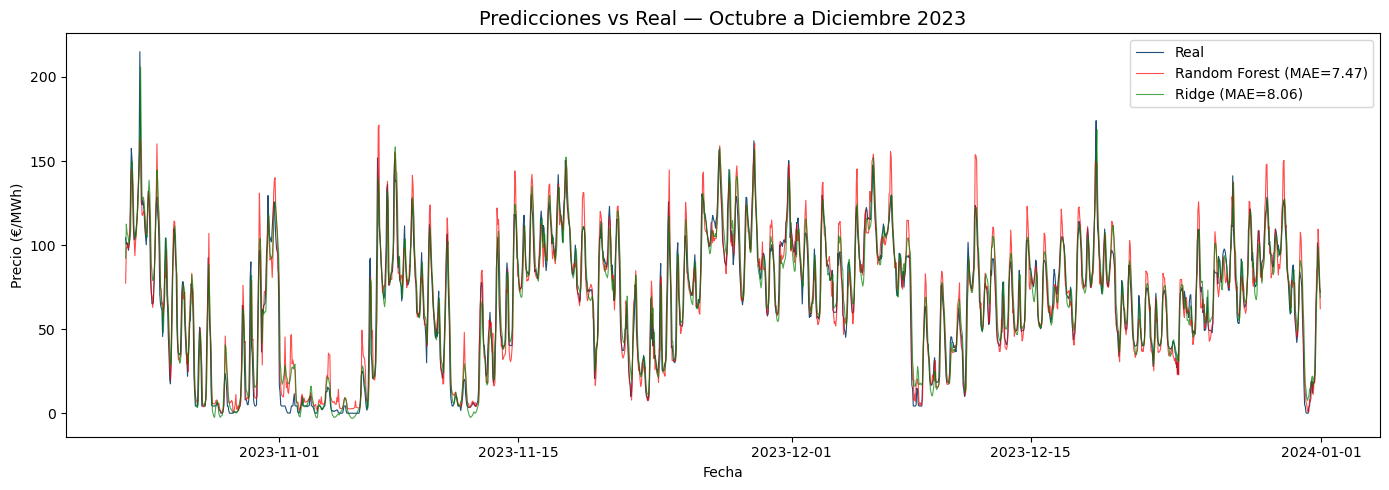

In [9]:
# Crear índice temporal para el test
datetime_test = pd.to_datetime(df["datetime"].iloc[split:]).reset_index(drop=True)

# Plot predicciones vs real
fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(datetime_test, y_test.reset_index(drop=True), 
        label="Real", color="#1F4E79", linewidth=0.8)
ax.plot(datetime_test, rf_pred, 
        label=f"Random Forest (MAE={rf_mae:.2f})", color="red", linewidth=0.8, alpha=0.7)
ax.plot(datetime_test, ridge_pred, 
        label=f"Ridge (MAE={ridge_mae:.2f})", color="green", linewidth=0.8, alpha=0.7)

ax.set_title("Predicciones vs Real — Octubre a Diciembre 2023", fontsize=14)
ax.set_xlabel("Fecha")
ax.set_ylabel("Precio (€/MWh)")
ax.legend()
plt.tight_layout()
plt.savefig("../outputs/predicciones_vs_real.png", dpi=150)
plt.show()